#### Importing the necessary libraries, frameworks, packages and modules

In [1]:
import os
import json
import pathlib

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

print("TensorFlow version:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices("GPU")))

TensorFlow version: 2.10.0
GPU available: True


#### Importing and downloading the required Banana Ripeness Classification Dataset from Kaggle

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shahriar26s/banana-ripeness-classification-dataset")

print("Path to dataset files:", path)

c:\Users\saifs\Downloads\bananavision\tfdml_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\saifs\.cache\kagglehub\datasets\shahriar26s\banana-ripeness-classification-dataset\versions\1


#### Creating a data folder where the dataset consisting of all the banana images are found, split into training, validation and test sets, represented by their corresponding subfolders under the data folder, and indicating the data folder's path as the location of the dataset in this project directory

In [3]:
IMG_SIZE = (224, 224)   # MobileNetV2's native input size; every image gets resized to this
BATCH_SIZE = 32          # how many images the model looks at per training step

# --- POINT THIS AT YOUR DATASET ---
# The Kaggle dataset already ships with train/valid/test splits, each containing
# one subfolder per ripeness class, so we point at each split directory separately.
DATA_DIR = pathlib.Path("../data/banana_ripeness")
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "valid"
TEST_DIR = DATA_DIR / "test"

for split_dir in (TRAIN_DIR, VAL_DIR, TEST_DIR):
    assert split_dir.exists(), (
        f"{split_dir} not found. Download a dataset (see Step B) and make sure it has "
        "train/valid/test folders, each containing one subfolder per ripeness stage."
    )

print("Class folders found:", sorted(p.name for p in TRAIN_DIR.iterdir() if p.is_dir()))


Class folders found: ['overripe', 'ripe', 'rotten', 'unripe']


#### Loading the images that live in the data folder into this notebook as our dataset, and then splitting into training, validation and test subsets

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(TRAIN_DIR, seed=123, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int")
val_ds = tf.keras.utils.image_dataset_from_directory(VAL_DIR, seed=123, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int")
test_ds = tf.keras.utils.image_dataset_from_directory(TEST_DIR, seed=123, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int")

class_names = train_ds.class_names
print("Classes (in label-index order):", class_names)
assert val_ds.class_names == class_names and test_ds.class_names == class_names, (
    "Class order mismatch between splits!"
)


Found 11793 files belonging to 4 classes.
Found 1123 files belonging to 4 classes.
Found 562 files belonging to 4 classes.
Classes (in label-index order): ['overripe', 'ripe', 'rotten', 'unripe']


#### Running checks and inspecting the dataset before building the model based on it, including making sure that the images are valid and load and display accurately and properly without breaking/failing, and ensuring that the class distributions across the 3 split subsets are more or less uniform

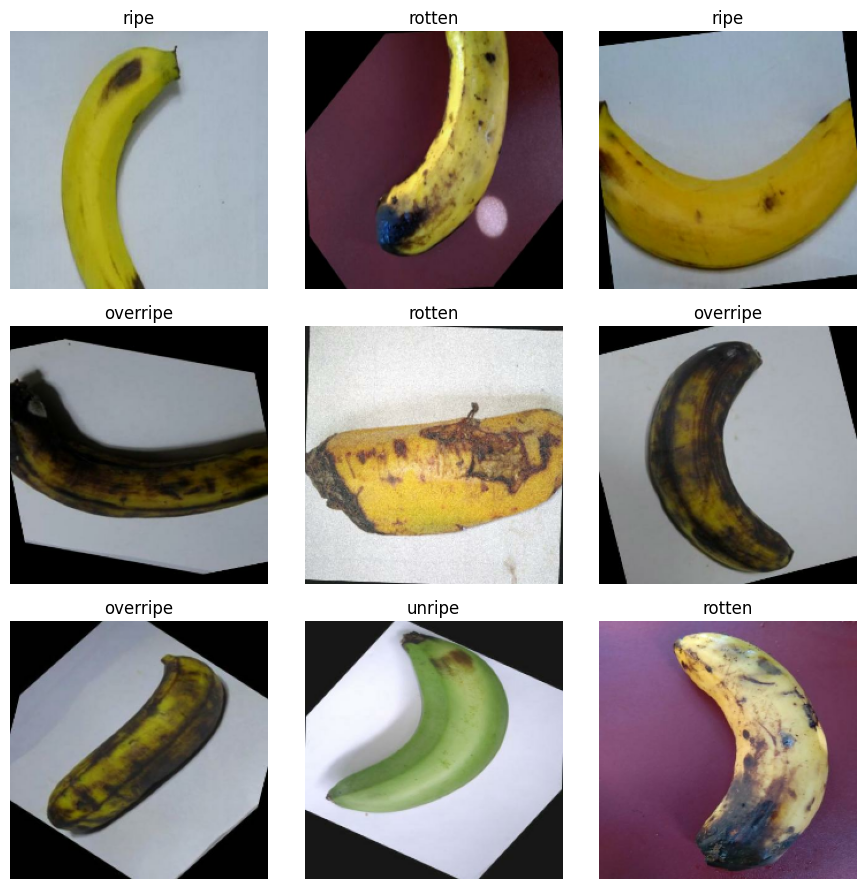

Images per class:
  train:
  overripe  : 2349
  ripe      : 3522
  rotten    : 4020
  unripe    : 1902
  valid:
  overripe  : 229
  ripe      : 339
  rotten    : 388
  unripe    : 167
  test:
  overripe  : 113
  ripe      : 154
  rotten    : 185
  unripe    : 110


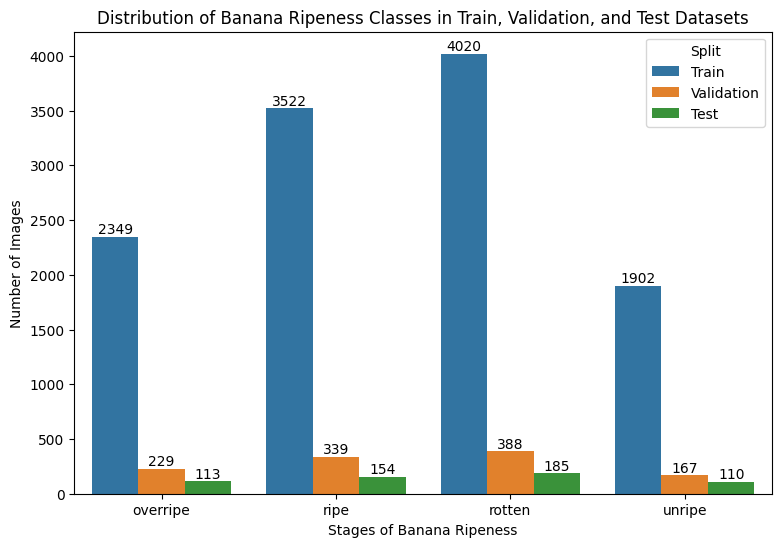

In [5]:
# 1) Sanity-check a batch of images against their labels
plt.figure(figsize=(9, 9))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))   # cast float pixels back to 0-255 ints to display
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
plt.tight_layout()
plt.show()

# 2) Check class balance (counts the files in each class folder)
print("Images per class:")
for class_dir in (TRAIN_DIR, VAL_DIR, TEST_DIR):
    print(f"  {class_dir.name}:")
    for c in class_names:
        n = len(list((class_dir / c).glob("*")))
        print(f"  {c:10s}: {n}")
        
# Data Visualization: Creating a bar chart to visualize the class distribution in all three datassets (train, validation, test).
def plot_class_distribution(class_names, train_dir, val_dir, test_dir):
    splits = [("Train", train_dir), ("Validation", val_dir), ("Test", test_dir)]
    classes, split_labels, counts = [], [], []
    for split_name, split_dir in splits:
        for c in class_names:
            classes.append(c)
            split_labels.append(split_name)
            counts.append(len(list((split_dir / c).glob("*"))))

    plt.figure(figsize=(9, 6))
    ax = sns.barplot(x=classes, y=counts, hue=split_labels)
    for container in ax.containers:
        ax.bar_label(container)
    plt.xlabel("Stages of Banana Ripeness")
    plt.ylabel("Number of Images")
    plt.title("Distribution of Banana Ripeness Classes in Train, Validation, and Test Datasets")
    plt.legend(title="Split")
    plt.show()

plot_class_distribution(class_names, TRAIN_DIR, VAL_DIR, TEST_DIR)


#### Speeding up the input pipeline

In [6]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
print("Input pipelines ready.")

Input pipelines ready.


#### Building a data-augmentation layer

In [7]:
data_augmentation = models.Sequential([layers.RandomFlip("horizontal"), layers.RandomRotation(0.1), layers.RandomZoom(0.1), layers.RandomContrast(0.1)], name="data_augmentation")

#### Assembling, building and developing the BananaVision model by fine-tuning a pre-existing, pre-trained model called MobileNetV2

In [8]:
def build_model(num_classes):
    '''
    Builds a MobileNetV2-based banana-stage classifier.
    - Inputs: num_classes (int) = number of ripeness stages
    - Returns: (model, base_model). We return the base separately so Part 4 can
      un-freeze part of it for fine-tuning.
    '''
    base_model = MobileNetV2(
        input_shape=IMG_SIZE + (3,),
        include_top=False,      # drop ImageNet's 1000-class head; we add our own
        weights="imagenet",     # start from pretrained visual features
    )
    base_model.trainable = False   # freeze the borrowed knowledge for now

    inputs = layers.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)          # random flips/rotations (training only)
    x = preprocess_input(x)                # scale pixels to [-1, 1] as MobileNetV2 expects
    x = base_model(x, training=False)      # frozen feature extractor
    x = layers.GlobalAveragePooling2D()(x) # 7x7x1280 grid -> 1280 vector
    x = layers.Dropout(0.2)(x)             # regularisation
    outputs = layers.Dense(num_classes, activation="softmax")(x)  # stage probabilities

    model = models.Model(inputs, outputs)
    return model, base_model


model, base_model = build_model(num_classes=len(class_names))


#### Compiling the model we just built and put together

In [9]:
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 data_augmentation (Sequenti  (None, 224, 224, 3)      0         
 al)                                                             
                                                                 
 tf.math.truediv (TFOpLambda  (None, 224, 224, 3)      0         


 )                                                               
                                                                 
 tf.math.subtract (TFOpLambd  (None, 224, 224, 3)      0         
 a)                                                              
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 dense (Dense)               (None, 4)                 5124      
                                                                 
Total para

#### Training the new head

In [10]:
callbacks = [tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True), tf.keras.callbacks.ModelCheckpoint("best_banana_model.keras", monitor="val_loss", save_best_only=True)]

history = model.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=callbacks)

Epoch 1/20
369/369 [==============================] - 1654s 4s/step - loss: 0.3120 - accuracy: 0.8888 - val_loss: 0.1709 - val_accuracy: 0.9448
Epoch 2/20
369/369 [==============================] - 1236s 3s/step - loss: 0.1790 - accuracy: 0.9401 - val_loss: 0.1390 - val_accuracy: 0.9519
Epoch 3/20
369/369 [==============================] - 1310s 4s/step - loss: 0.1540 - accuracy: 0.9484 - val_loss: 0.1356 - val_accuracy: 0.9564
Epoch 4/20
369/369 [==============================] - 2292s 6s/step - loss: 0.1402 - accuracy: 0.9532 - val_loss: 0.1150 - val_accuracy: 0.9662
Epoch 5/20
369/369 [==============================] - 697s 2s/step - loss: 0.1310 - accuracy: 0.9572 - val_loss: 0.1351 - val_accuracy: 0.9510
Epoch 6/20
369/369 [==============================] - 1002s 3s/step - loss: 0.1244 - accuracy: 0.9564 - val_loss: 0.1112 - val_accuracy: 0.9697
Epoch 7/20
369/369 [==============================] - 1016s 3s/step - loss: 0.1227 - accuracy: 0.9578 - val_loss: 0.1107 - val_accuracy: 

#### Fine-tuning and optimizing the model further

In [11]:
# Un-freeze only the last 30 layers of the base
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile REQUIRED after changing trainable flags; note the 100x smaller LR
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks,
)

Epoch 1/10
369/369 [==============================] - 756s 2s/step - loss: 0.1125 - accuracy: 0.9620 - val_loss: 0.1026 - val_accuracy: 0.9706
Epoch 2/10
369/369 [==============================] - 881s 2s/step - loss: 0.0813 - accuracy: 0.9726 - val_loss: 0.1042 - val_accuracy: 0.9671
Epoch 3/10
369/369 [==============================] - 570s 2s/step - loss: 0.0701 - accuracy: 0.9764 - val_loss: 0.0916 - val_accuracy: 0.9715
Epoch 4/10
369/369 [==============================] - 573s 2s/step - loss: 0.0619 - accuracy: 0.9786 - val_loss: 0.0782 - val_accuracy: 0.9795
Epoch 5/10
369/369 [==============================] - 674s 2s/step - loss: 0.0536 - accuracy: 0.9810 - val_loss: 0.0823 - val_accuracy: 0.9804
Epoch 6/10
369/369 [==============================] - 615s 2s/step - loss: 0.0474 - accuracy: 0.9835 - val_loss: 0.0627 - val_accuracy: 0.9813
Epoch 7/10
369/369 [==============================] - 611s 2s/step - loss: 0.0447 - accuracy: 0.9850 - val_loss: 0.0652 - val_accuracy: 0.9822

#### Producing the results of training the model, fine-tuning the model after the training stage, then testing it on new, previously-unseen images data; Obtaining the results and performance of the model; Evaluating accuracy, precision, recall, F1 scores; Plotting, observing and analyzing the confusion matrix

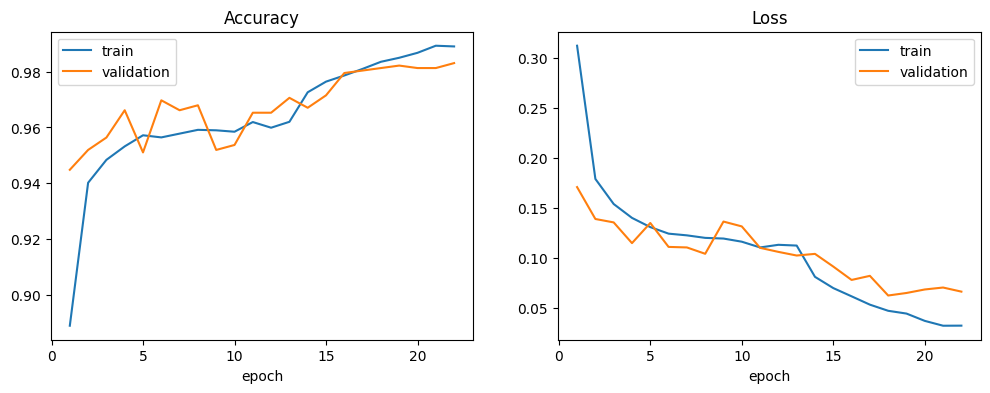

In [12]:
def plot_history(*histories):
    '''Concatenate one or more Keras History objects and plot accuracy & loss.'''
    acc, val_acc, loss, val_loss = [], [], [], []
    for h in histories:
        acc += h.history["accuracy"]
        val_acc += h.history["val_accuracy"]
        loss += h.history["loss"]
        val_loss += h.history["val_loss"]

    epochs = range(1, len(acc) + 1)
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label="train")
    plt.plot(epochs, val_acc, label="validation")
    plt.title("Accuracy"); plt.xlabel("epoch"); plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label="train")
    plt.plot(epochs, val_loss, label="validation")
    plt.title("Loss"); plt.xlabel("epoch"); plt.legend()
    plt.show()


# Pass both phases if you fine-tuned; otherwise just plot_history(history)
plot_history(history, history_ft)


              precision    recall  f1-score   support

    overripe       0.97      0.99      0.98       229
        ripe       0.99      0.98      0.99       339
      rotten       0.98      0.97      0.98       388
      unripe       0.98      0.99      0.99       167

    accuracy                           0.98      1123
   macro avg       0.98      0.98      0.98      1123
weighted avg       0.98      0.98      0.98      1123



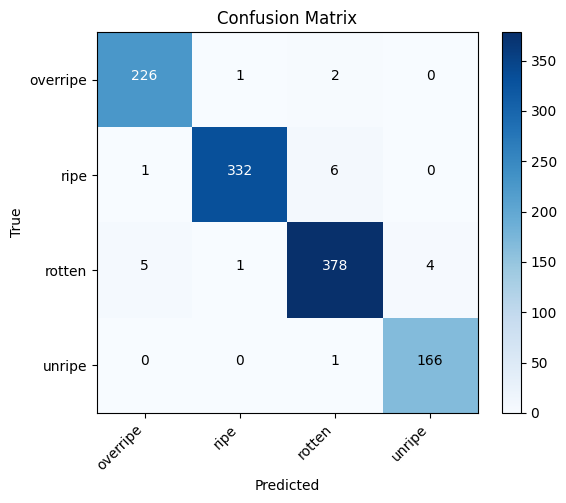

In [13]:
from sklearn.metrics import confusion_matrix, classification_report

y_true, y_pred = [], []
for images, labels in val_ds:
    probs = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(probs, axis=1))
    y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(range(len(class_names)), class_names)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix")
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(); plt.tight_layout(); plt.show()


#### Mapping the folder names where the image datasets for the four types/stages of bananas live to the 4 standard stage names that we have defined and specified for use in this project, in order to maintain this standard and remain consistent throughout this project

In [14]:
STAGE_ORDER = ["unripe", "ripe", "overripe", "rotten"]

STAGE_ALIASES = {
    "green": "unripe", "freshunripe": "unripe", "semiripe": "unripe", "semi-ripe": "unripe",
    "yellow": "ripe", "freshripe": "ripe", "fresh": "ripe",
    "spotted": "overripe", "brown": "overripe",
    "rotten": "rotten", "spoiled": "rotten", "black": "rotten",
}

def canonical_stage(name):
    '''Map a dataset folder name (any casing/spelling) to one of STAGE_ORDER.'''
    key = name.strip().lower().replace(" ", "").replace("_", "").replace("-", "")
    if key in STAGE_ORDER:
        return key
    return STAGE_ALIASES.get(key, key)  # falls back to the raw key if unmapped

# Map each model output index -> canonical stage, in the model's label order:
CANON_BY_INDEX = [canonical_stage(c) for c in class_names]
print("Model index -> canonical stage:", dict(enumerate(CANON_BY_INDEX)))


Model index -> canonical stage: {0: 'overripe', 1: 'ripe', 2: 'rotten', 3: 'unripe'}


#### Creating a function that calculates the shelf life/expected probable number of days remaining until it rots and goes bad, in the form of a probability-weighted number

In [15]:
DAYS_BY_STAGE = {
    "unripe":   7.0,   # firm & green: about a week before it's at its best-then-declining
    "ripe":     3.0,   # yellow, maybe light flecks: a few good days
    "overripe": 1.0,   # heavy spots/soft: roughly a day of eating window
    "rotten":   0.0,   # past it
}

def expected_days_remaining(probs):
    '''
    Continuous shelf-life estimate from the full probability vector.
    - Input: probs = 1-D array of class probabilities in the model's label order
    - Returns: (point_estimate_days, low_days, high_days)
    '''
    point = 0.0
    for p, stage in zip(probs, CANON_BY_INDEX):
        point += float(p) * DAYS_BY_STAGE.get(stage, 0.0)

    # crude range: consider stages the model gives >=10% probability
    considered = [DAYS_BY_STAGE.get(s, 0.0)
                  for p, s in zip(probs, CANON_BY_INDEX) if p >= 0.10]
    low = min(considered) if considered else point
    high = max(considered) if considered else point
    return round(point, 1), round(low, 1), round(high, 1)


#### Creating a function that determines whether the banana scanned by the user is edible or not, based on the stage determined by the Convolutional Neural Network model (simple yes/no or True/False determination)

In [16]:
def is_edible(stage):
    '''Returns True unless the banana is rotten. Safety-relevant, so it stays a code rule.'''
    return stage != "rotten"


#### Loading the document containing all the key, crucial, intuitive information about the various stages of the banana (including essential nutrients, benefits, what's missing, potential risks, who it's encouraged for, and who should limit or avoid it) and parsing it so the appropriate stages and the subsections of that stage are displayed to the user

In [17]:
import sys
sys.path.insert(0, "../api")          # so 'banana_content' is importable from train/

from banana_content import load_stage_guide, missing_pieces

# Parse the cited document into per-stage content (the same shape the app serves)
GUIDE = load_stage_guide("../api/banana_stages.md")

# Fail loudly if an edit dropped a stage or renamed a heading, rather than
# silently serving blank fields to users:
gaps = missing_pieces(GUIDE)
assert not gaps, f"banana_stages.md is missing content: {gaps}"

print("Loaded stages:", [s for s in GUIDE if s in STAGE_ORDER])
print("Sections per stage:", list(GUIDE["ripe"].keys()))


Loaded stages: ['unripe', 'ripe', 'overripe', 'rotten']
Sections per stage: ['nutrients', 'benefits', 'missing', 'risks', 'encouraged_for', 'avoid_or_limit']


####  Preprocessing an arbitrary photo the user scans and uploads, converting it into a form that our Convolutional Neural Network can operate on and process

In [18]:
from PIL import Image

def preprocess_image(image):
    '''
    Accepts a file path (str) or a PIL.Image and returns a (1, 224, 224, 3) float batch.
    Does NOT scale pixels - the model's built-in preprocess_input handles that.
    '''
    if isinstance(image, str):
        image = Image.open(image)
    image = image.convert("RGB").resize(IMG_SIZE)
    arr = np.asarray(image, dtype="float32")
    return np.expand_dims(arr, axis=0)   # add batch dimension -> shape (1, 224, 224, 3)

#### Running the full workflow using a sample test image scanned and uploaded by the user

In [19]:
def analyze_banana(image):
    '''
    The single entry point the app calls.
    - Input: file path or PIL.Image of one banana
    - Returns: dict with stage, confidence, shelf life, edibility, and the
      per-stage guide (nutrients, benefits, missing, risks, encouraged_for,
      avoid_or_limit) read from banana_stages.md
    '''
    batch = preprocess_image(image)
    probs = model.predict(batch, verbose=0)[0]      # 1-D probability vector
    top_idx = int(np.argmax(probs))
    stage = CANON_BY_INDEX[top_idx]
    confidence = float(probs[top_idx])

    point, low, high = expected_days_remaining(probs)

    return {
        "stage": stage,
        "confidence": round(confidence, 3),
        "edible": is_edible(stage),
        "days_remaining": {"estimate": point, "low": low, "high": high},
        "guide": GUIDE.get(stage, {}),   # six prose fields from the document
        "all_probabilities": {CANON_BY_INDEX[i]: round(float(p), 3)
                              for i, p in enumerate(probs)},
    }


#### Testing the workflow by running it

In [20]:
sample = "../app/assets/test_image.jpeg"   # <- set to a real image to try it
print(json.dumps(analyze_banana(sample), indent=2))
print("Set `sample` to a real image path, then uncomment the line above to test.")

{
  "stage": "ripe",
  "confidence": 0.781,
  "edible": true,
  "days_remaining": {
    "estimate": 3.8,
    "low": 3.0,
    "high": 7.0
  },
  "guide": {
    "nutrients": "As the starch converts, a yellow, ripe banana carries a balanced mix of simple sugars\n(glucose, fructose, and sucrose) with a smaller, declining amount of resistant starch\n[3][5]. Potassium, vitamin B6, and vitamin C remain at their usual levels [1], and the\nphenolic antioxidants that develop during ripening are now present [4].",
    "benefits": "This is the easiest stage to digest and the best all-rounder. The simple sugars give\nquick, accessible energy; potassium supports healthy blood pressure and normal muscle\nand nerve function; and vitamin B6 helps the body turn food into energy [6]. Its glycemic\nindex is still in the low range (studies report roughly 51 for a ripe banana in reference\ndatabases, and about 60 for a well-ripened one) [5][6], so for most people it is a\ngentle, everyday choice.",
    "mis

#### Converting the full, heavyduty Keras model into a more lightweight version in TFLite / LiteRT that can be easily and conveniently rendered onto a server for free

In [21]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Rebuild the model WITHOUT data_augmentation. The augmentation layers are only
# meant for training, but TFLiteConverter has no training/inference switch, so it
# bakes the random flip/rotate/contrast ops into the exported graph and corrupts
# every prediction. Dropout is dropped too (it's a no-op at inference anyway).
inputs = layers.Input(shape=IMG_SIZE + (3,))
x = preprocess_input(inputs)                                  # scale to [-1, 1]
x = model.get_layer("mobilenetv2_1.00_224")(x, training=False)
x = model.get_layer("global_average_pooling2d")(x)
outputs = model.get_layer("dense")(x)
infer_model = models.Model(inputs, outputs)

converter = tf.lite.TFLiteConverter.from_keras_model(infer_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

write_path = "banana_model.tflite"
with open(write_path, "wb") as f:
    f.write(tflite_model)

print("Wrote banana_model.tflite:", len(tflite_model) // 1024, "KB")


INFO:tensorflow:Assets written to: C:\Users\saifs\AppData\Local\Temp\tmpd6d0watd\assets


INFO:tensorflow:Assets written to: C:\Users\saifs\AppData\Local\Temp\tmpd6d0watd\assets


Wrote banana_model.tflite: 2454 KB


#### Saving and exporting the important configuration settings, numbers, data and information needed for the entire workflow, the code/programs written, and the final trained, fine-tuned, optimized model, to an external JSON file

In [22]:
config = {
    "canon_by_index": CANON_BY_INDEX,   # model output order -> canonical stage
    "days_by_stage": DAYS_BY_STAGE,     # for the probability-weighted days estimate
    "img_size": list(IMG_SIZE),         # so the server preprocesses exactly as training did
}
with open("banana_config.json", "w") as f:
    json.dump(config, f, indent=2)
print("Wrote banana_config.json")

Wrote banana_config.json
